# Синтетические функции — аппроксимация MLP

> Сорочан Дмитрий, [@legenda0008](https://t.me/legenda0008)

Третий тип данных из условия -- **синтетические функции**. Здесь истинная функция известна, поэтому влияние архитектуры можно увидеть напрямую, а не только через classification accuracy.

Использую три функции разной формы и отдельно строю heatmap depth × width для первой функции.


In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn


SEED = 143
REPORT_DIR = Path("report")
FIGURES_DIR = REPORT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

DEPTHS = [1, 2, 5, 10, 20, 50, 100]
WIDTHS = [8, 16, 32, 64, 128]
EPOCHS = 800
LR = 1e-2

sns.set_theme(style="whitegrid")


In [2]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def f_smooth(x):
    return np.sin(3 * x) + 0.3 * np.cos(7 * x)


def f_compositional(x):
    return np.sin(2 * x + 0.8 * np.sin(5 * x))


def f_piecewise(x):
    return 0.6 * np.abs(x) + 0.4 * np.sin(6 * x)


FUNCTIONS = {
    "smooth": f_smooth,
    "compositional": f_compositional,
    "piecewise": f_piecewise,
}


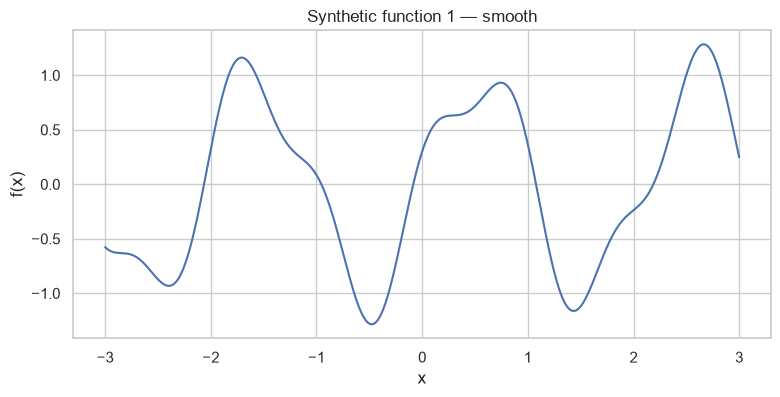

In [3]:
x_plot = np.linspace(-3, 3, 1000)

plt.figure(figsize=(9, 4))
plt.plot(x_plot, f_smooth(x_plot))
plt.title("Synthetic function 1 — smooth")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.savefig(FIGURES_DIR / "synthetic_function_smooth.png", bbox_inches="tight")
plt.show()


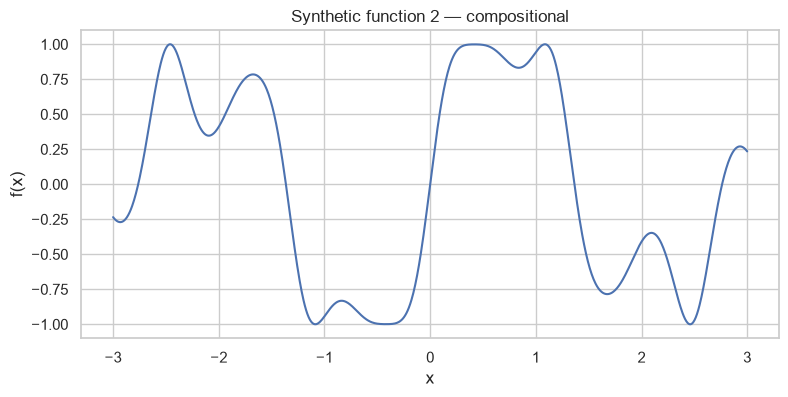

In [4]:
plt.figure(figsize=(9, 4))
plt.plot(x_plot, f_compositional(x_plot))
plt.title("Synthetic function 2 — compositional")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.savefig(FIGURES_DIR / "synthetic_function_compositional.png", bbox_inches="tight")
plt.show()


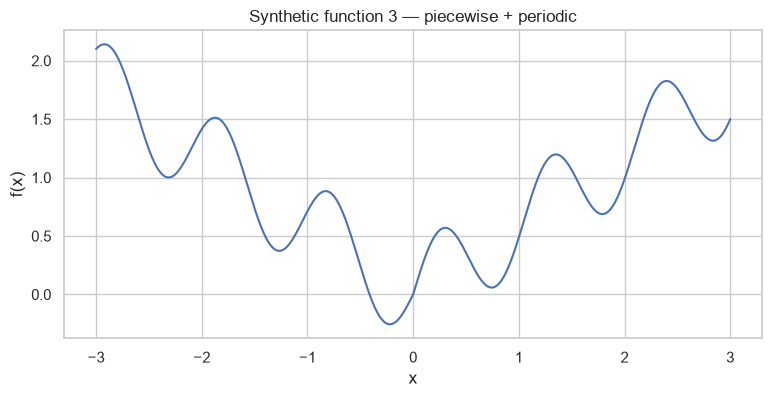

In [5]:
plt.figure(figsize=(9, 4))
plt.plot(x_plot, f_piecewise(x_plot))
plt.title("Synthetic function 3 — piecewise + periodic")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.savefig(FIGURES_DIR / "synthetic_function_piecewise.png", bbox_inches="tight")
plt.show()


In [6]:
class RegressionMLP(nn.Module):
    def __init__(self, depth, width):
        super().__init__()

        layers = []
        in_features = 1

        for _ in range(depth):
            layers.append(nn.Linear(in_features, width))
            layers.append(nn.Tanh())
            in_features = width

        layers.append(nn.Linear(in_features, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def make_data(function, n_train=400, noise=0.08):
    rng = np.random.default_rng(SEED)
    x_train = rng.uniform(-3, 3, size=n_train).astype(np.float32)
    y_train = function(x_train).astype(np.float32)
    y_train += rng.normal(0, noise, size=n_train).astype(np.float32)

    x_test = np.linspace(-3, 3, 1000, dtype=np.float32)
    y_test = function(x_test).astype(np.float32)

    return (
        torch.from_numpy(x_train[:, None]).to(DEVICE),
        torch.from_numpy(y_train[:, None]).to(DEVICE),
        torch.from_numpy(x_test[:, None]).to(DEVICE),
        torch.from_numpy(y_test[:, None]).to(DEVICE),
    )


def fit_regressor(function, depth, width, epochs=EPOCHS):
    set_seed()
    X_train, y_train, X_test, y_test = make_data(function)

    model = RegressionMLP(depth, width).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        prediction = model(X_train)
        loss = loss_fn(prediction, y_train)
        loss.backward()
        optimizer.step()

        if epoch == 1 or epoch % 20 == 0 or epoch == epochs:
            model.eval()
            with torch.no_grad():
                test_loss = loss_fn(model(X_test), y_test).item()
            history.append({
                "epoch": epoch,
                "train_mse": loss.item(),
                "test_mse": test_loss,
            })

    model.eval()
    with torch.no_grad():
        prediction = model(X_test).cpu().numpy().ravel()
        test_mse = loss_fn(model(X_test), y_test).item()

    return model, pd.DataFrame(history), X_test.cpu().numpy().ravel(), prediction, test_mse


## Heatmap width × depth


In [7]:
synthetic_grid = []

for depth in DEPTHS:
    for width in WIDTHS:
        print(f"depth={depth}, width={width}")
        model, history, x_test, prediction, test_mse = fit_regressor(
            f_smooth,
            depth,
            width,
        )

        synthetic_grid.append({
            "function": "smooth",
            "depth": depth,
            "width": width,
            "parameters": count_parameters(model),
            "test_mse": test_mse,
        })

synthetic_grid = pd.DataFrame(synthetic_grid)
synthetic_grid.to_csv(REPORT_DIR / "synthetic_grid_results.csv", index=False)
synthetic_grid.sort_values("test_mse").head(10)


depth=1, width=8
depth=1, width=16
depth=1, width=32
depth=1, width=64
depth=1, width=128
depth=2, width=8
depth=2, width=16
depth=2, width=32
depth=2, width=64
depth=2, width=128
depth=5, width=8
depth=5, width=16
depth=5, width=32
depth=5, width=64
depth=5, width=128
depth=10, width=8
depth=10, width=16
depth=10, width=32
depth=10, width=64
depth=10, width=128
depth=20, width=8
depth=20, width=16
depth=20, width=32
depth=20, width=64
depth=20, width=128
depth=50, width=8
depth=50, width=16
depth=50, width=32
depth=50, width=64
depth=50, width=128
depth=100, width=8
depth=100, width=16
depth=100, width=32
depth=100, width=64
depth=100, width=128


,function,depth,width,parameters,test_mse
12,smooth,5,32,4321,0.001002
14,smooth,5,128,66433,0.001210
8,smooth,2,64,4353,0.001330
17,smooth,10,32,9601,0.002369
9,smooth,2,128,16897,0.002801
11,smooth,5,16,1137,0.003065
18,smooth,10,64,37633,0.003337
13,smooth,5,64,16833,0.003680
7,smooth,2,32,1153,0.006727
10,smooth,5,8,313,0.009824


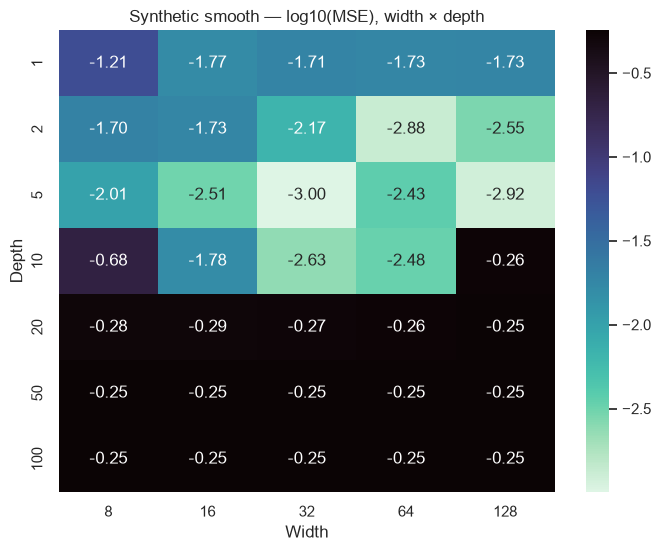

In [8]:
mse_heatmap = synthetic_grid.pivot(index="depth", columns="width", values="test_mse")

plt.figure(figsize=(8, 6))
sns.heatmap(np.log10(mse_heatmap), annot=True, fmt=".2f", cmap="mako_r")
plt.title("Synthetic smooth — log10(MSE), width × depth")
plt.xlabel("Width")
plt.ylabel("Depth")
plt.savefig(FIGURES_DIR / "synthetic_mse_heatmap.png", bbox_inches="tight")
plt.show()


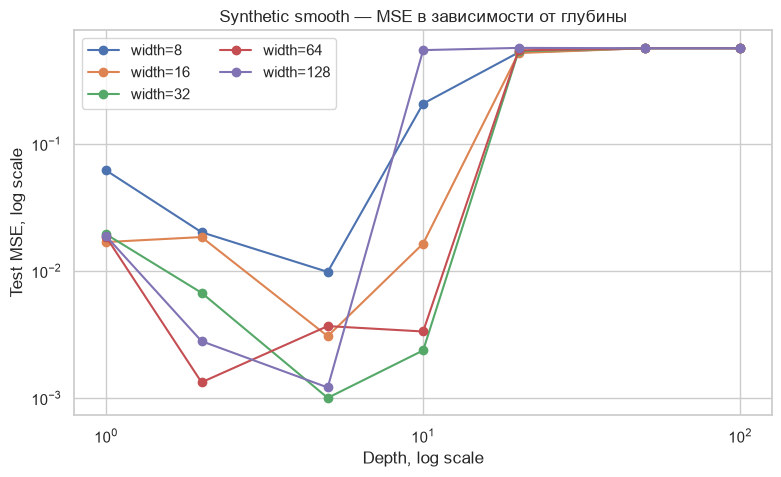

In [9]:
plt.figure(figsize=(9, 5))
for width in WIDTHS:
    part = synthetic_grid[synthetic_grid["width"] == width]
    plt.plot(part["depth"], part["test_mse"], marker="o", label=f"width={width}")

plt.xscale("log")
plt.yscale("log")
plt.title("Synthetic smooth — MSE в зависимости от глубины")
plt.xlabel("Depth, log scale")
plt.ylabel("Test MSE, log scale")
plt.legend(ncol=2)
plt.savefig(FIGURES_DIR / "synthetic_mse_vs_depth.png", bbox_inches="tight")
plt.show()


## Shallow vs deep на трёх функциях


In [10]:
COMPARE_CONFIGS = [(1, 128), (5, 64), (20, 32)]
comparison_rows = []
comparison_predictions = {}
comparison_histories = {}

for function_name, function in FUNCTIONS.items():
    for depth, width in COMPARE_CONFIGS:
        print(function_name, depth, width)
        model, history, x_test, prediction, test_mse = fit_regressor(
            function,
            depth,
            width,
        )

        comparison_rows.append({
            "function": function_name,
            "depth": depth,
            "width": width,
            "parameters": count_parameters(model),
            "test_mse": test_mse,
        })
        comparison_predictions[(function_name, depth, width)] = (x_test, prediction)
        comparison_histories[(function_name, depth, width)] = history

comparison_results = pd.DataFrame(comparison_rows)
comparison_results.to_csv(REPORT_DIR / "synthetic_comparison.csv", index=False)
comparison_results


smooth 1 128
smooth 5 64
smooth 20 32
compositional 1 128
compositional 5 64
compositional 20 32
piecewise 1 128
piecewise 5 64
piecewise 20 32


,function,depth,width,parameters,test_mse
0,smooth,1,128,385,0.018777
1,smooth,5,64,16833,0.003680
2,smooth,20,32,20161,0.535128
3,compositional,1,128,385,0.048838
4,compositional,5,64,16833,0.002327
5,compositional,20,32,20161,0.522236
6,piecewise,1,128,385,0.059204
7,piecewise,5,64,16833,0.001355
8,piecewise,20,32,20161,0.352941


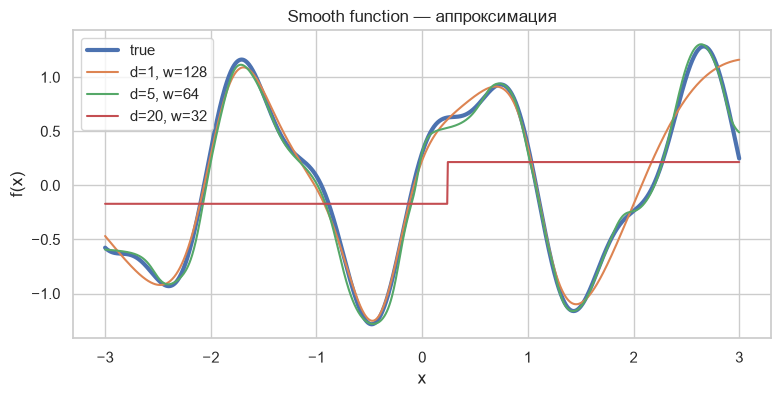

In [11]:
plt.figure(figsize=(9, 4))
plt.plot(x_plot, f_smooth(x_plot), linewidth=3, label="true")
for depth, width in COMPARE_CONFIGS:
    x_test, prediction = comparison_predictions[("smooth", depth, width)]
    plt.plot(x_test, prediction, label=f"d={depth}, w={width}")
plt.title("Smooth function — аппроксимация")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.savefig(FIGURES_DIR / "synthetic_approximation_smooth.png", bbox_inches="tight")
plt.show()


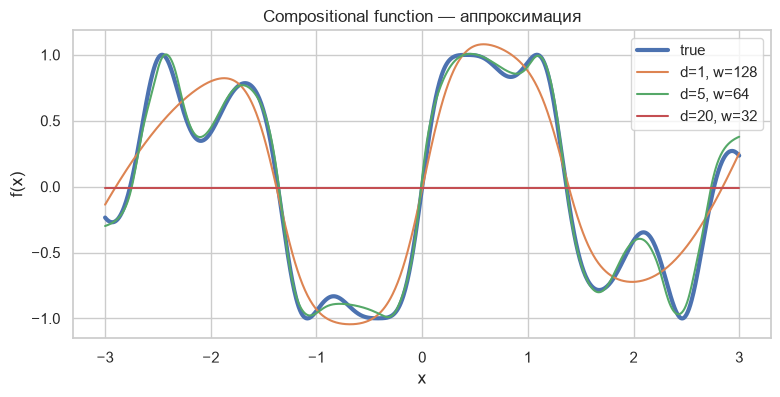

In [12]:
plt.figure(figsize=(9, 4))
plt.plot(x_plot, f_compositional(x_plot), linewidth=3, label="true")
for depth, width in COMPARE_CONFIGS:
    x_test, prediction = comparison_predictions[("compositional", depth, width)]
    plt.plot(x_test, prediction, label=f"d={depth}, w={width}")
plt.title("Compositional function — аппроксимация")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.savefig(FIGURES_DIR / "synthetic_approximation_compositional.png", bbox_inches="tight")
plt.show()


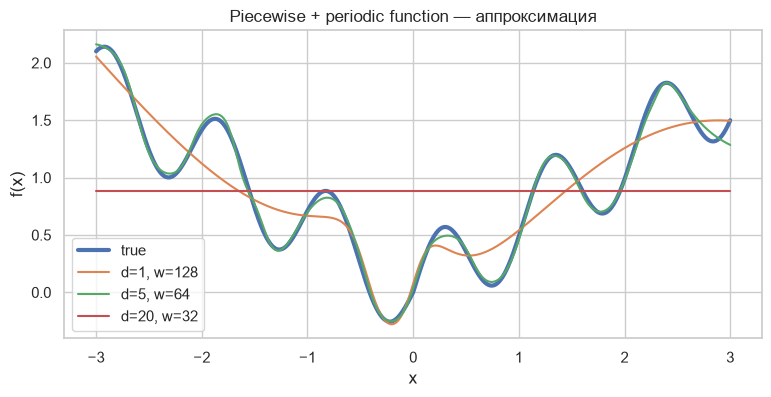

In [13]:
plt.figure(figsize=(9, 4))
plt.plot(x_plot, f_piecewise(x_plot), linewidth=3, label="true")
for depth, width in COMPARE_CONFIGS:
    x_test, prediction = comparison_predictions[("piecewise", depth, width)]
    plt.plot(x_test, prediction, label=f"d={depth}, w={width}")
plt.title("Piecewise + periodic function — аппроксимация")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.savefig(FIGURES_DIR / "synthetic_approximation_piecewise.png", bbox_inches="tight")
plt.show()


## Learning curve на синтетической функции


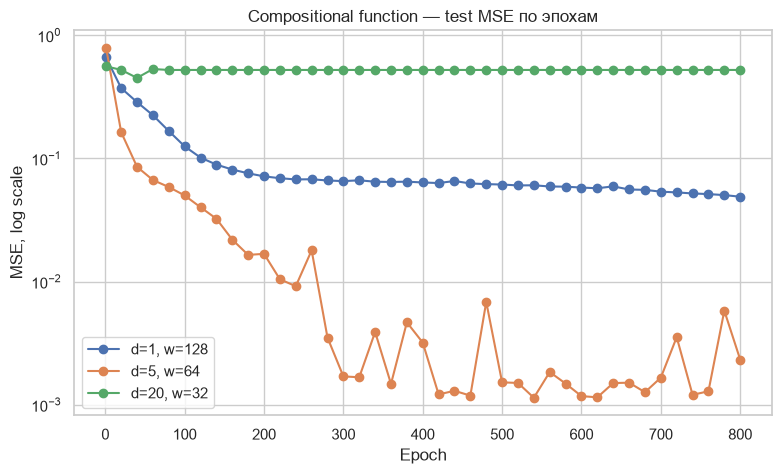

In [14]:
plt.figure(figsize=(9, 5))
for depth, width in COMPARE_CONFIGS:
    history = comparison_histories[("compositional", depth, width)]
    plt.plot(history["epoch"], history["test_mse"], marker="o", label=f"d={depth}, w={width}")

plt.yscale("log")
plt.title("Compositional function — test MSE по эпохам")
plt.xlabel("Epoch")
plt.ylabel("MSE, log scale")
plt.legend()
plt.savefig(FIGURES_DIR / "synthetic_learning_curve.png", bbox_inches="tight")
plt.show()


In [15]:
required_files = [
    REPORT_DIR / "mnist_architecture_results.csv",
    REPORT_DIR / "fashion_architecture_results.csv",
    REPORT_DIR / "mlp_final_results.csv",
    REPORT_DIR / "model_comparison.csv",
    REPORT_DIR / "synthetic_grid_results.csv",
]

if all(path.exists() for path in required_files):
    mnist_grid = pd.read_csv(REPORT_DIR / "mnist_architecture_results.csv")
    fashion_grid = pd.read_csv(REPORT_DIR / "fashion_architecture_results.csv")
    final_mlp = pd.read_csv(REPORT_DIR / "mlp_final_results.csv")
    comparison = pd.read_csv(REPORT_DIR / "model_comparison.csv")
    synthetic = pd.read_csv(REPORT_DIR / "synthetic_grid_results.csv")

    best_mnist = mnist_grid.sort_values("val_accuracy", ascending=False).iloc[0]
    best_fashion = fashion_grid.sort_values("val_accuracy", ascending=False).iloc[0]
    best_synthetic = synthetic.sort_values("test_mse").iloc[0]

    lines = [
        r"\subsection{Численные результаты}",
        r"\begin{center}",
        r"\begin{tabular}{lrrrr}",
        r"\toprule",
        "Dataset & Depth & Width & Validation accuracy & Macro-F1 \\\\",
        r"\midrule",
        f"MNIST & {int(best_mnist.depth)} & {int(best_mnist.width)} & {best_mnist.val_accuracy:.4f} & {best_mnist.val_macro_f1:.4f} \\\\",
        f"Fashion-MNIST & {int(best_fashion.depth)} & {int(best_fashion.width)} & {best_fashion.val_accuracy:.4f} & {best_fashion.val_macro_f1:.4f} \\\\",
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{center}",
        "",
        r"\begin{center}",
        r"\begin{tabular}{lrr}",
        r"\toprule",
        "Dataset & Final test accuracy & Final test macro-F1 \\\\",
        r"\midrule",
    ]

    for row in final_mlp.itertuples(index=False):
        lines.append(f"{row.dataset} & {row.test_accuracy:.4f} & {row.test_macro_f1:.4f} \\\\")

    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{center}",
        "",
        f"Лучшая синтетическая конфигурация на $f_1$: depth={int(best_synthetic.depth)}, width={int(best_synthetic.width)}, MSE={best_synthetic.test_mse:.6f}.",
    ]

    for dataset in ["MNIST", "Fashion-MNIST"]:
        part = comparison[comparison["dataset"] == dataset].sort_values("val_accuracy", ascending=False)
        best_model = part.iloc[0]
        lines.append(
            f"Лучший validation baseline для {dataset}: {best_model['model']}, accuracy={best_model.val_accuracy:.4f}, macro-F1={best_model.val_macro_f1:.4f}."
        )

    (REPORT_DIR / "results.tex").write_text("\n".join(lines), encoding="utf-8")
    print("report/results.tex updated")
else:
    print("Сначала выполните предыдущие ноутбуки — для results.tex нужны их CSV.")

Сначала выполните предыдущие ноутбуки — для results.tex нужны их CSV.


## Выводы $\textcolor{red}{\#TODO}$ конкретизировать по результатам выполнения -- на конкретных примерах функций и архитектур

Синтетический эксперимент нужен именно как иллюстрация теоремы об аппроксимации:

- shallow-сеть действительно способна приблизить функцию, если дать ей достаточно ширины;
- увеличение глубины может дать более компактное представление сложной формы;
- очень большая глубина сама по себе не гарантирует низкий MSE -- оптимизация plain MLP может ухудшаться;
- поэтому корректный вывод должен учитывать одновременно `depth`, `width`, число параметров и learning curve.
